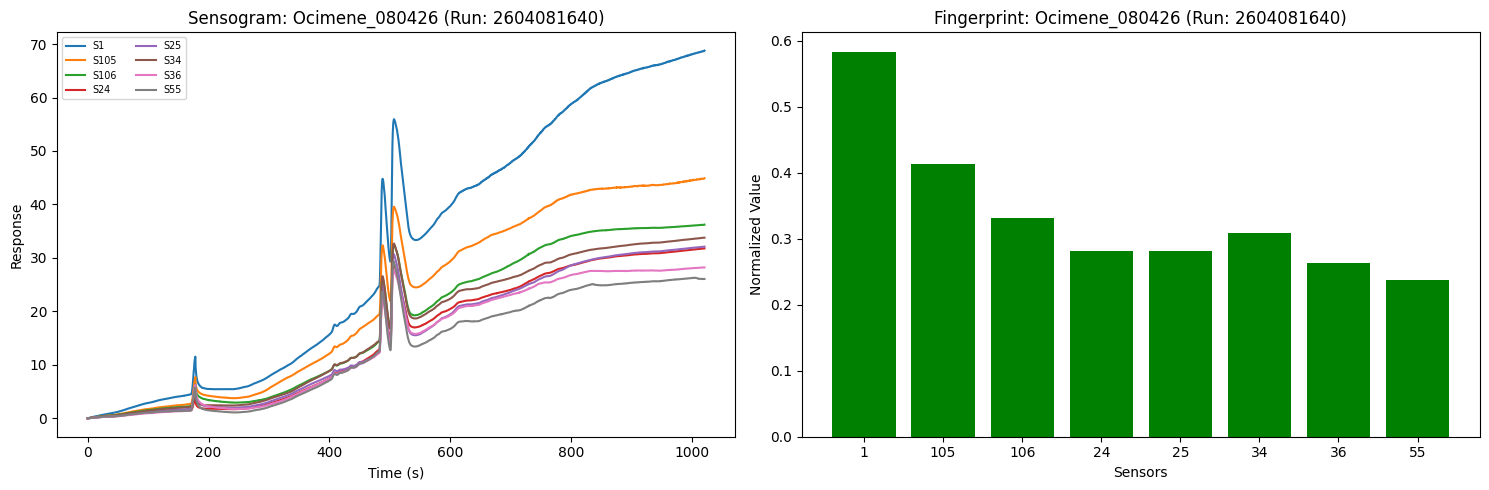

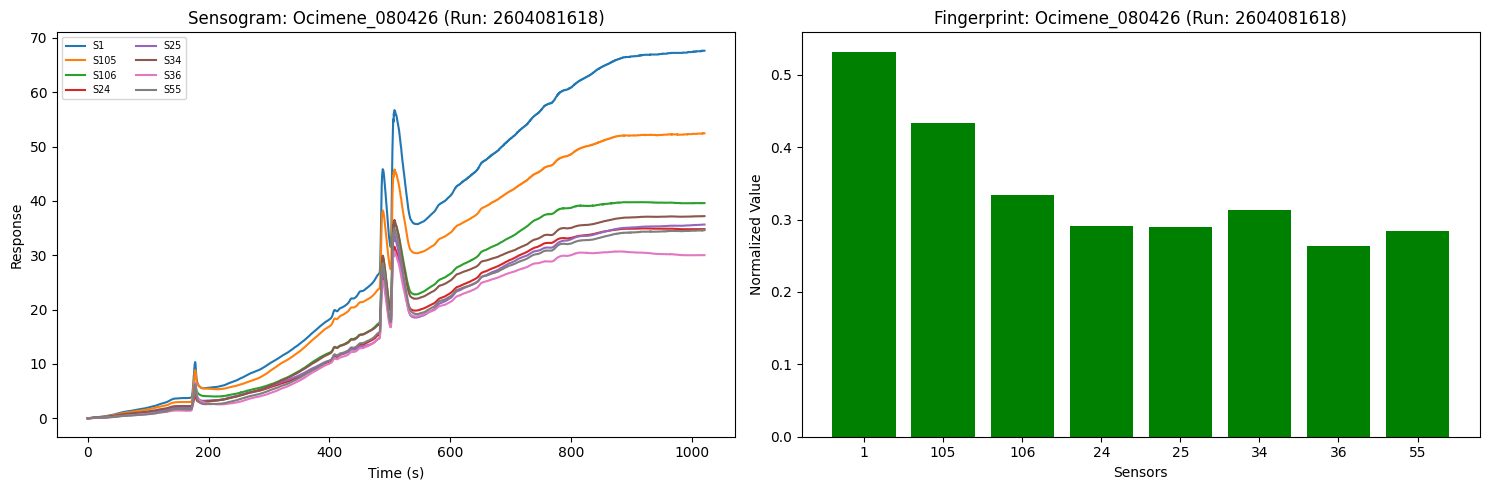

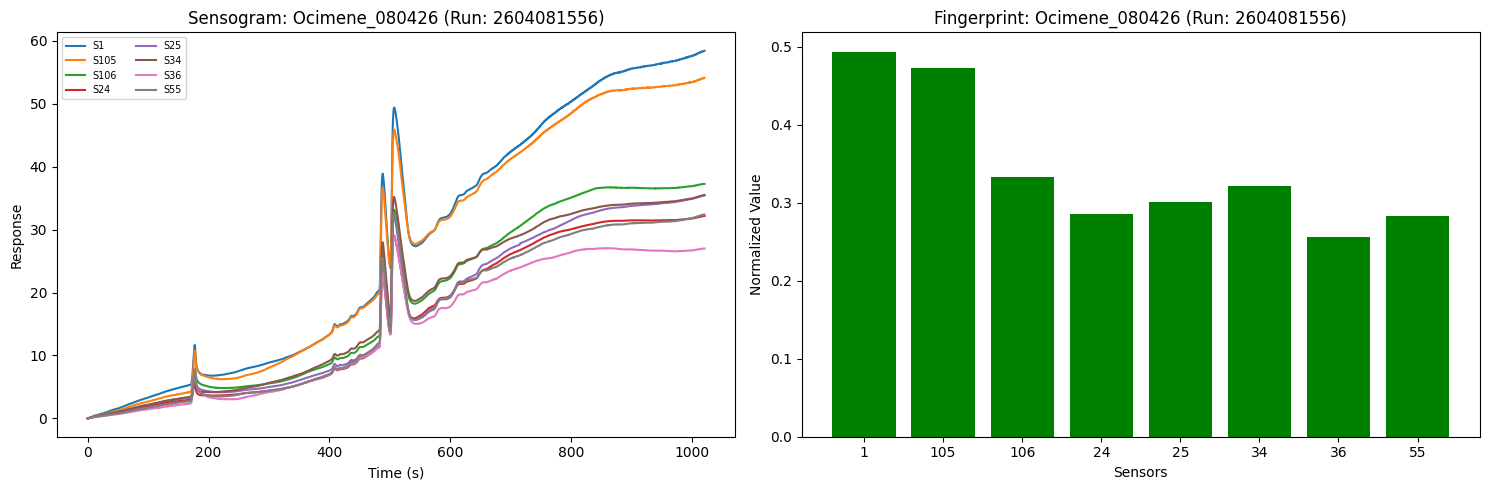

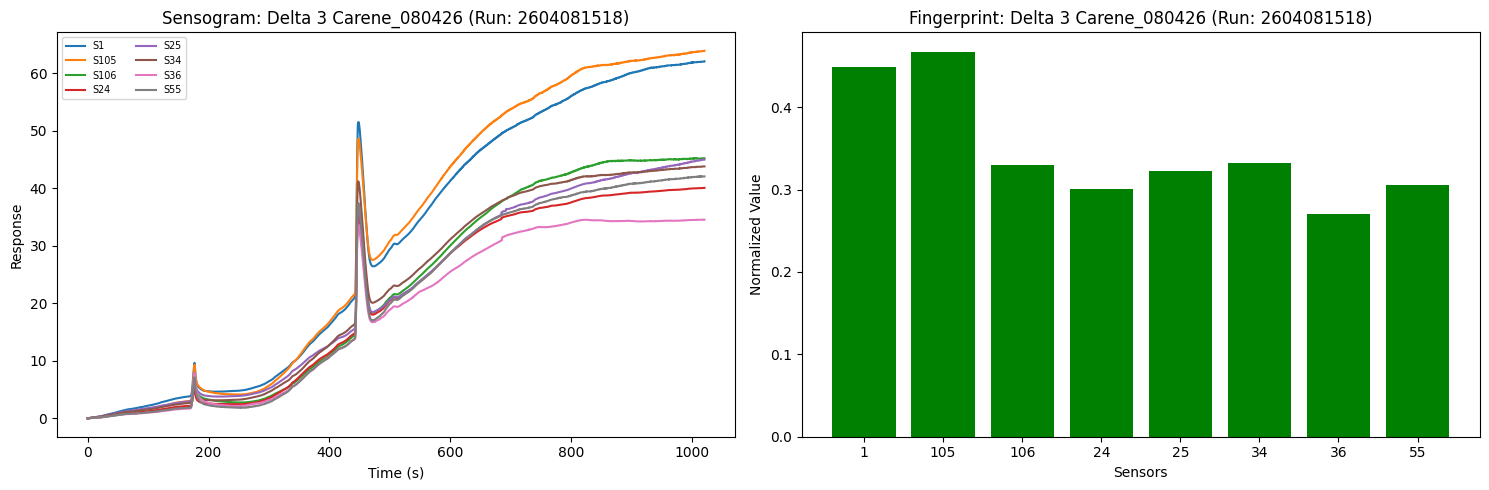

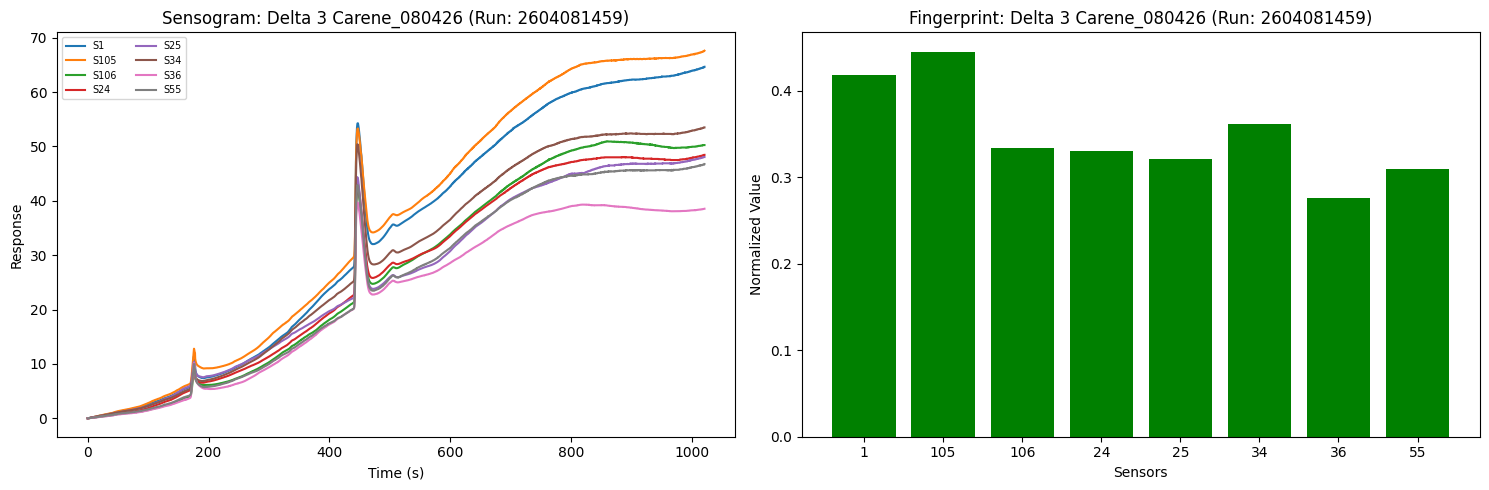

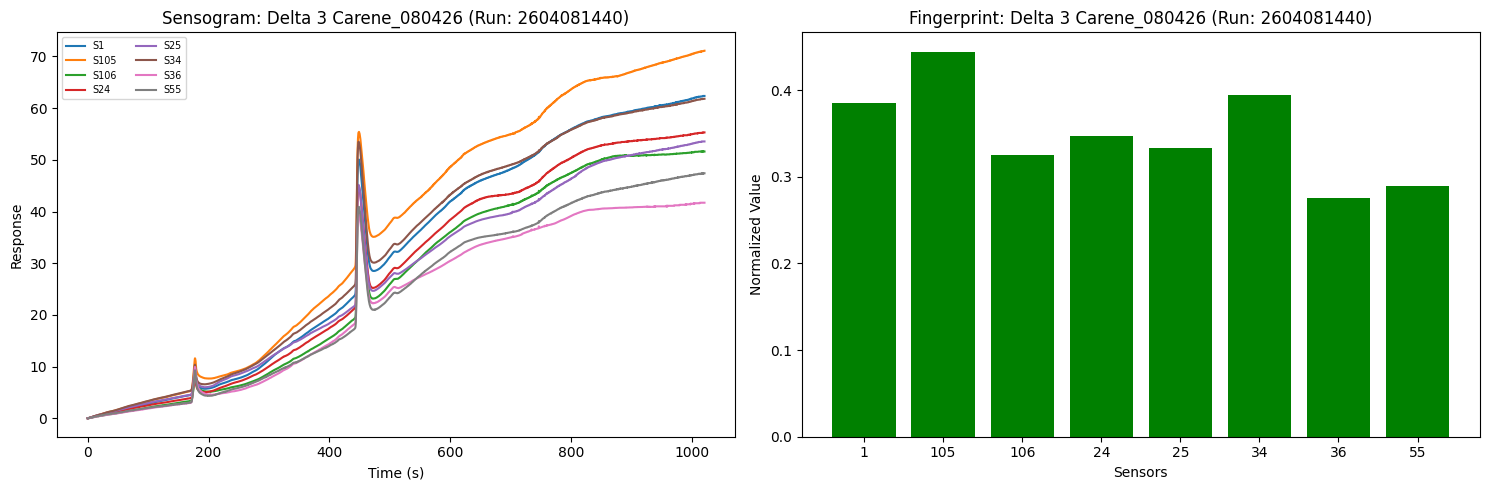

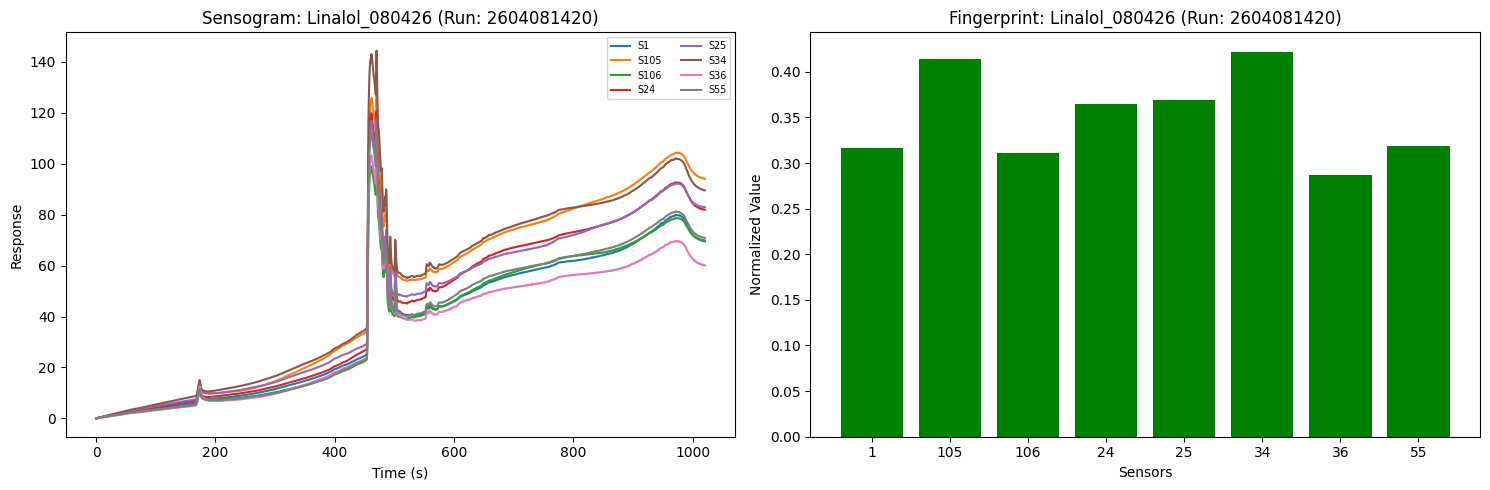

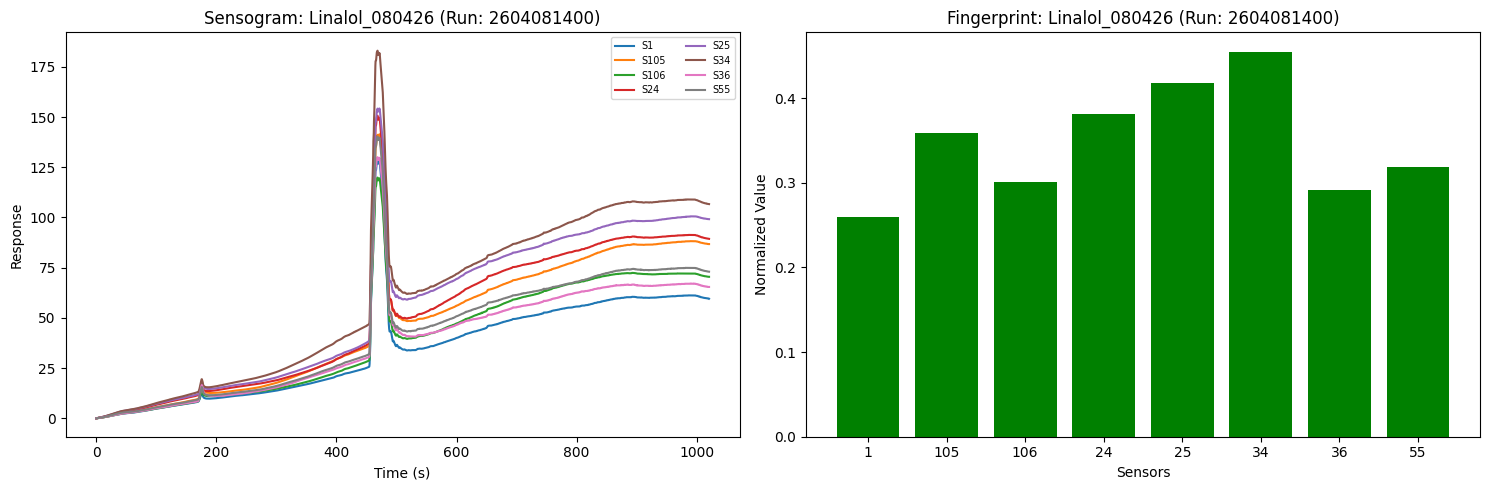

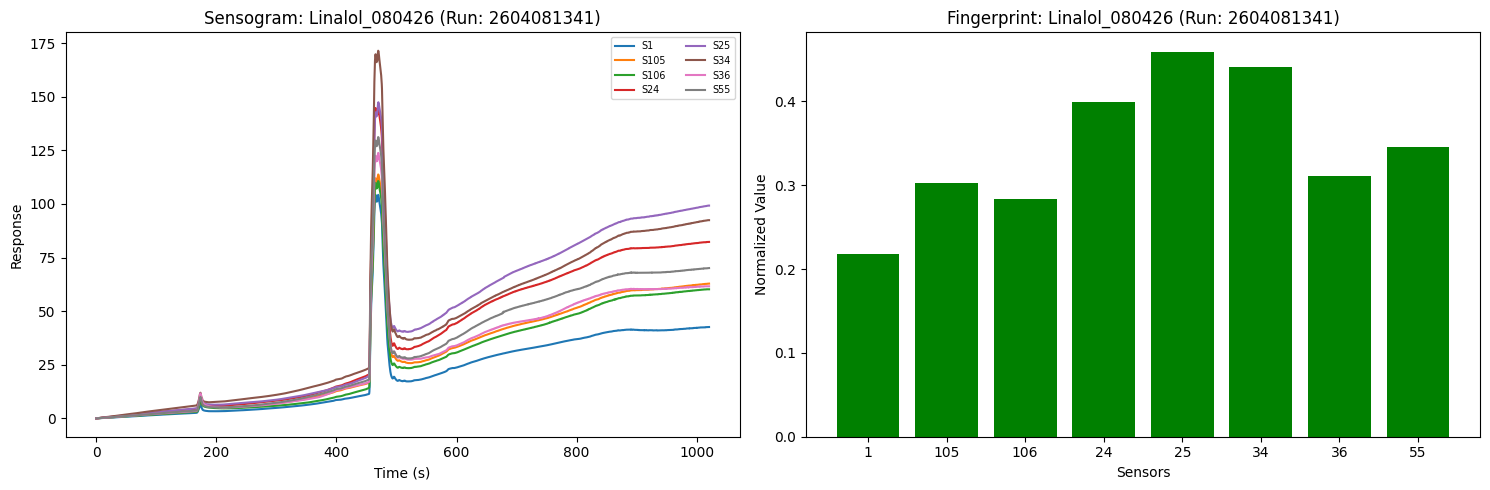

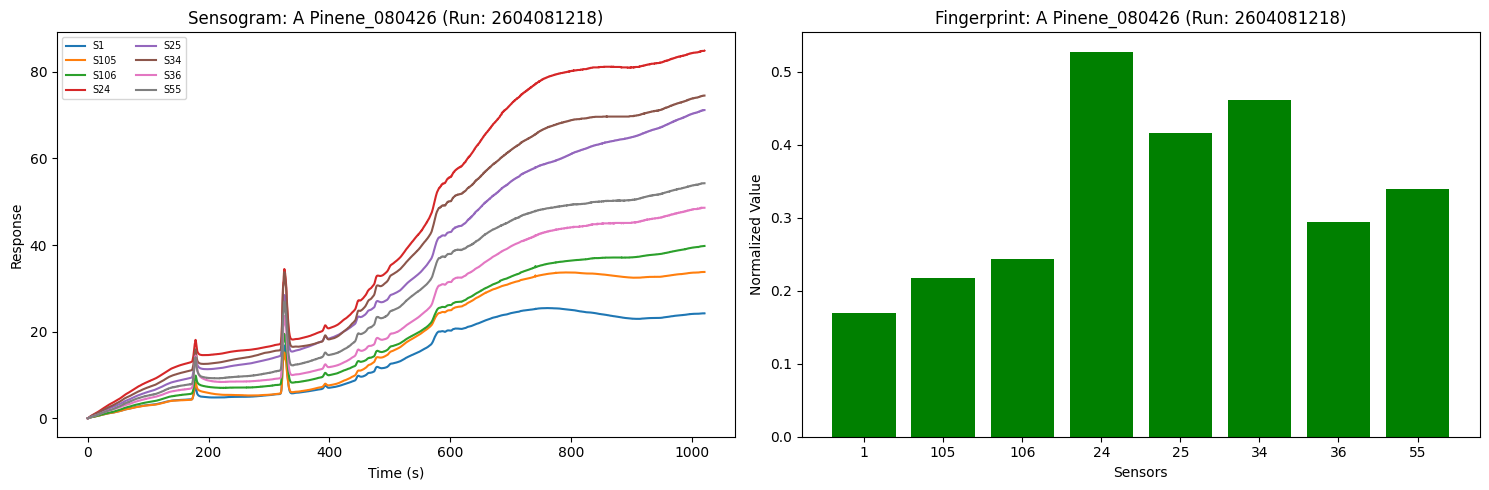

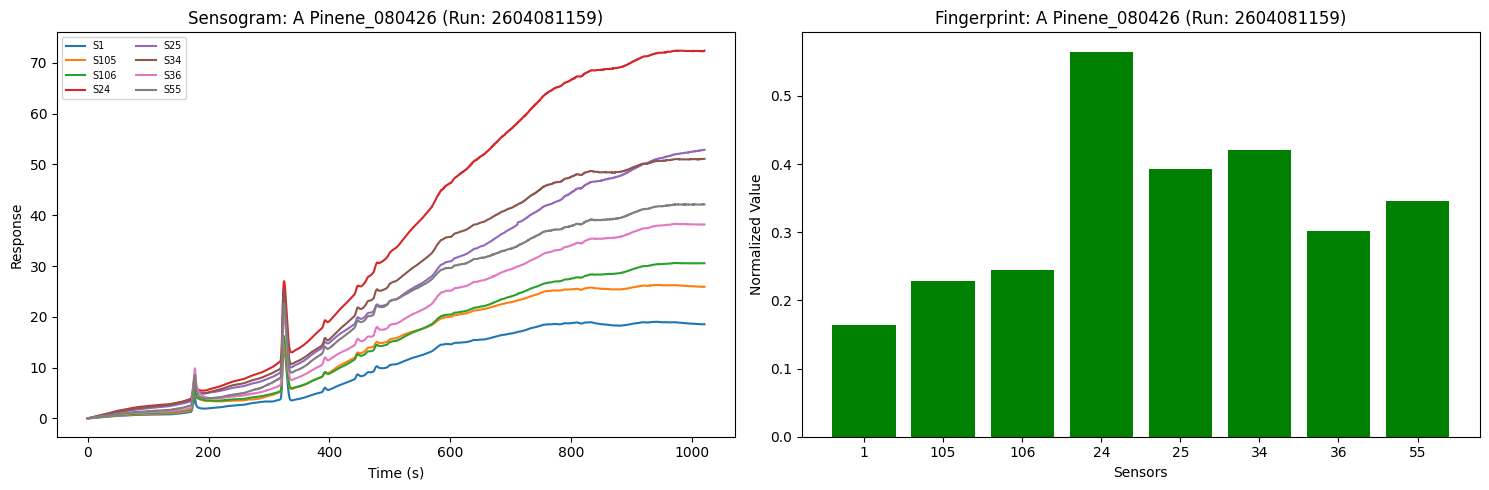

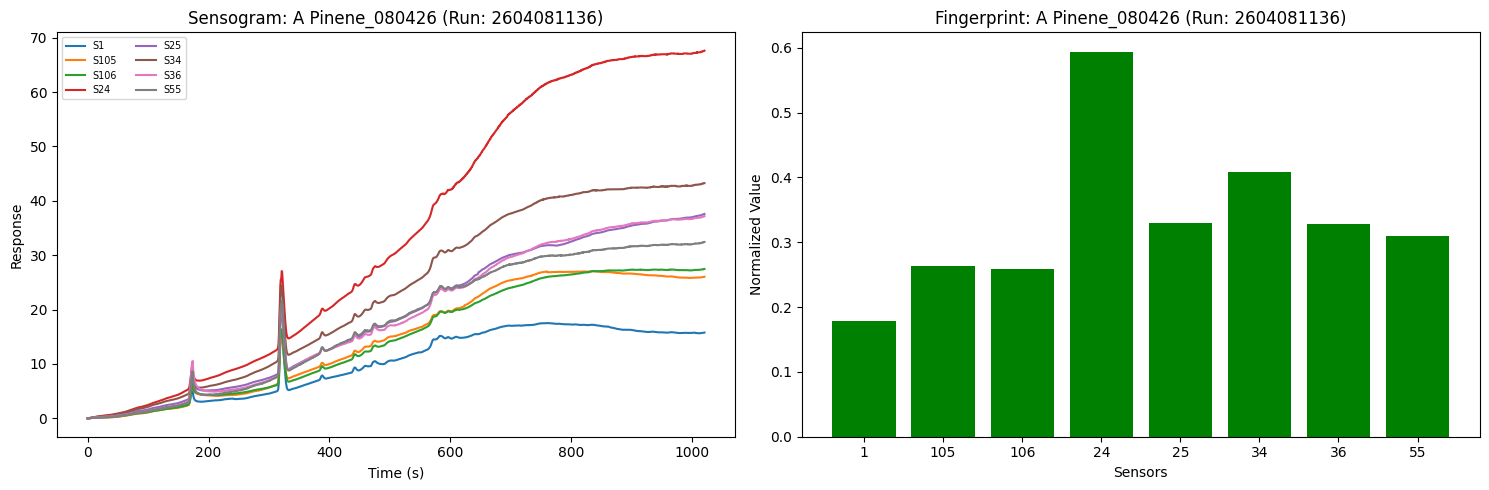

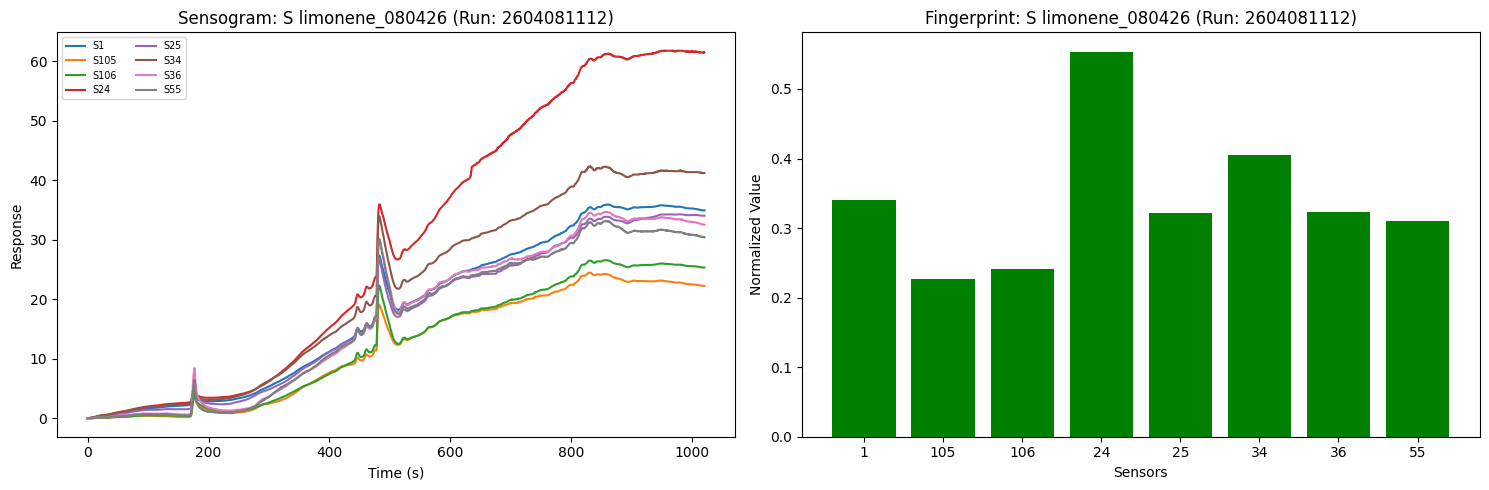

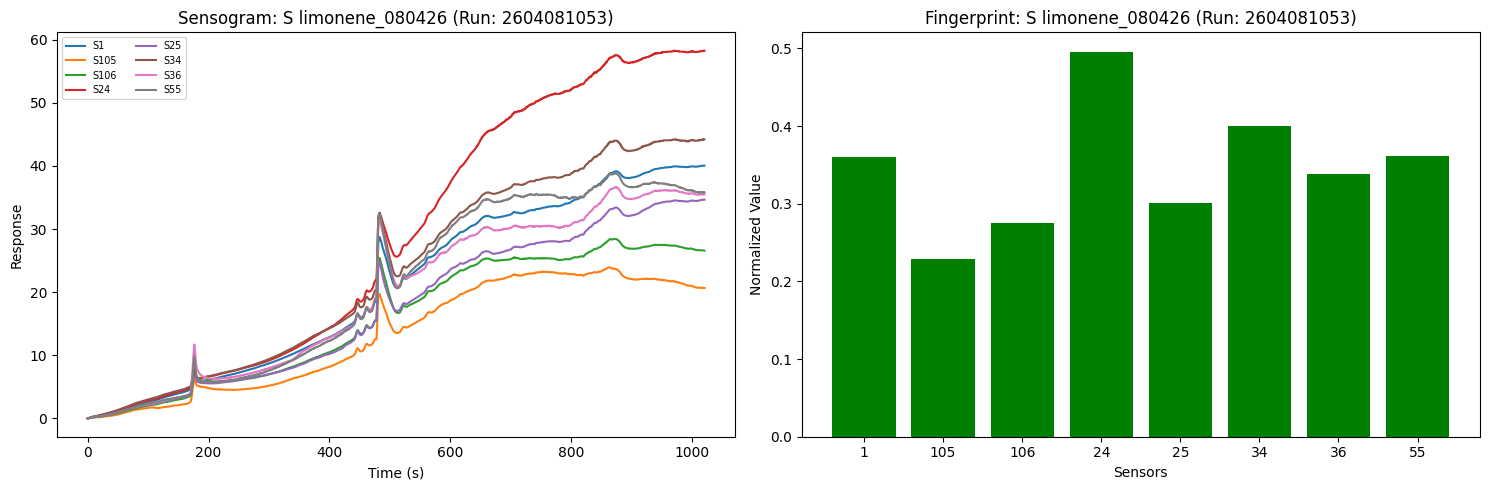

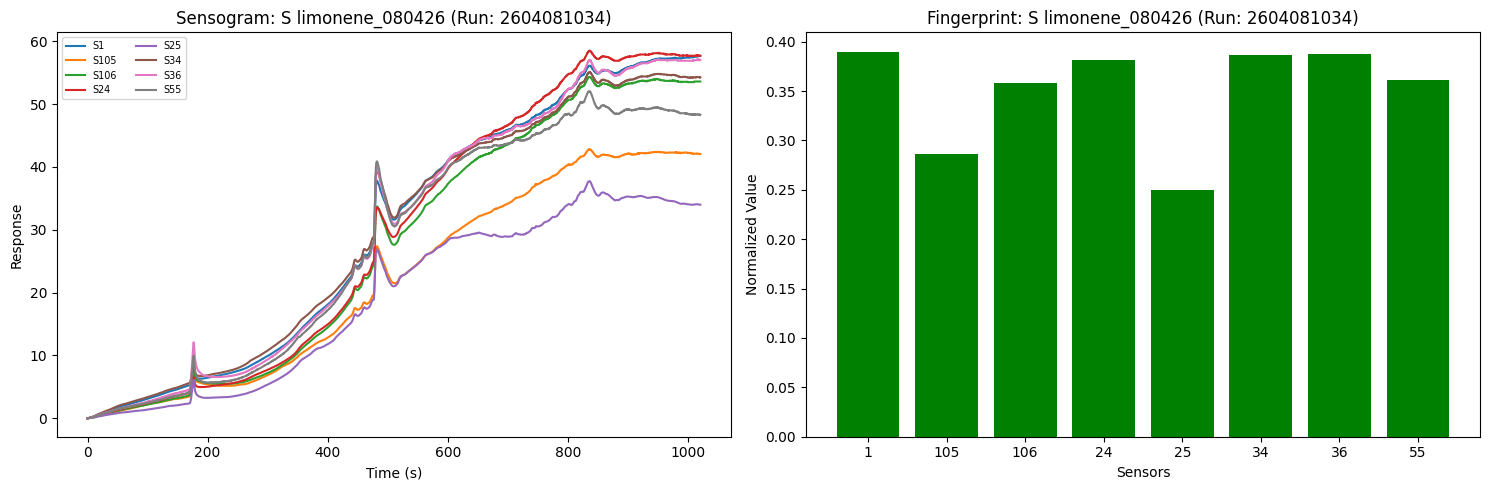

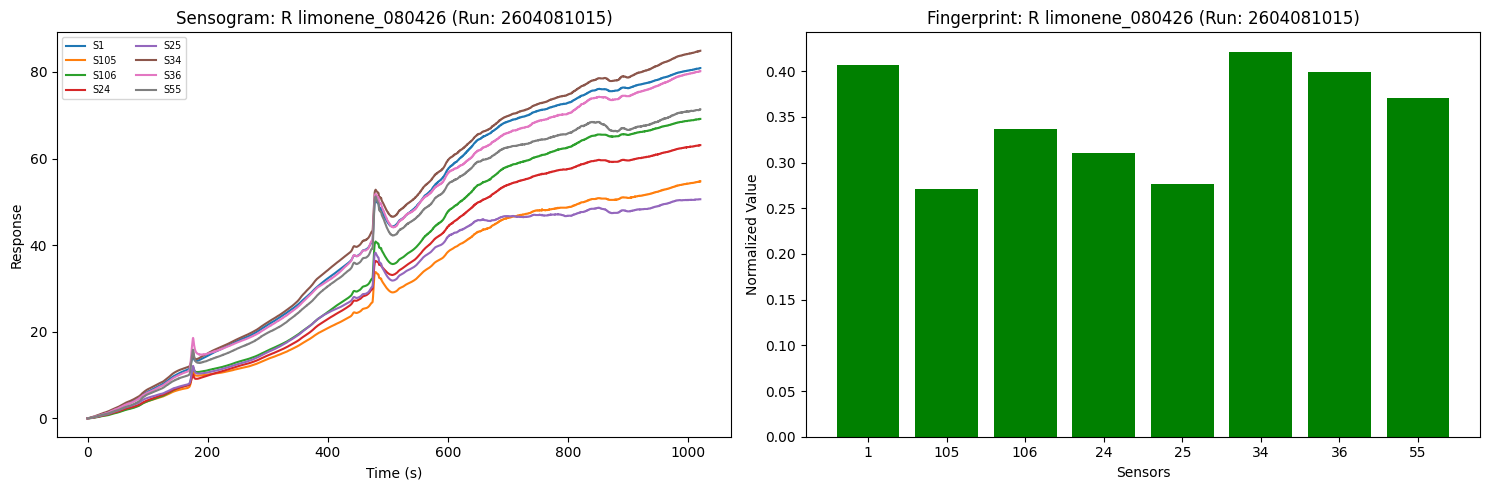

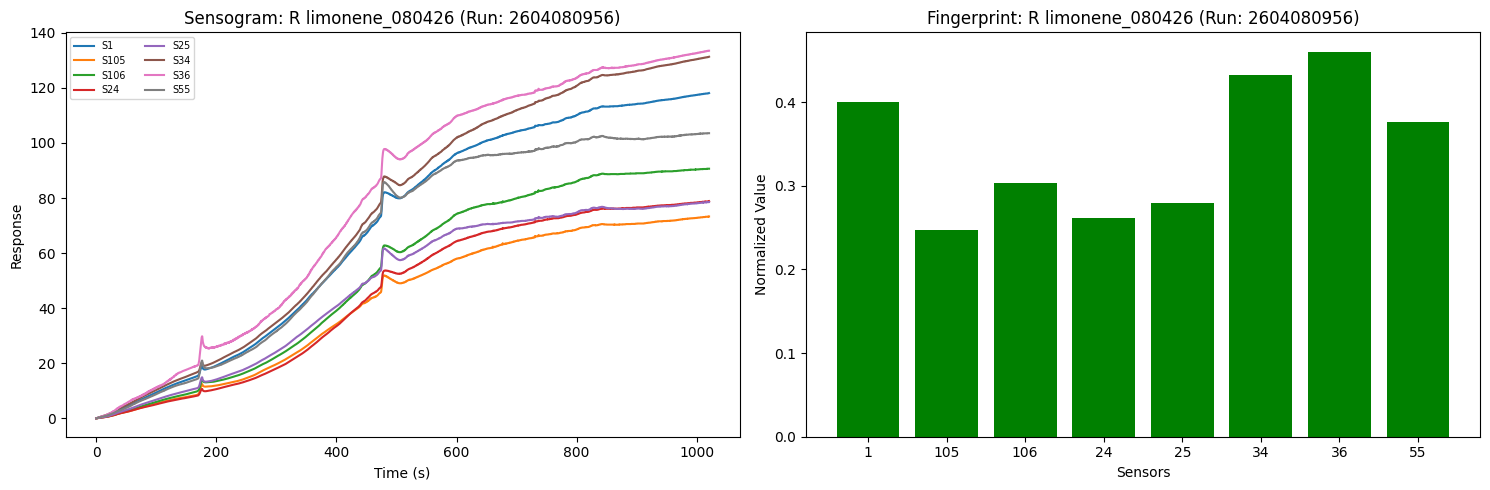

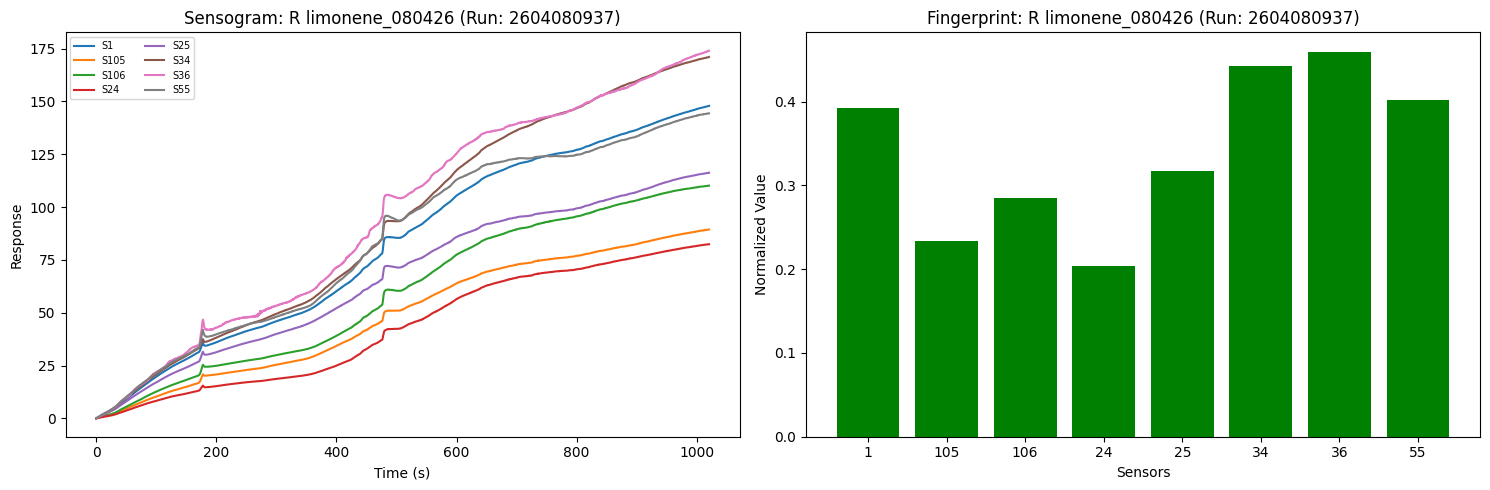

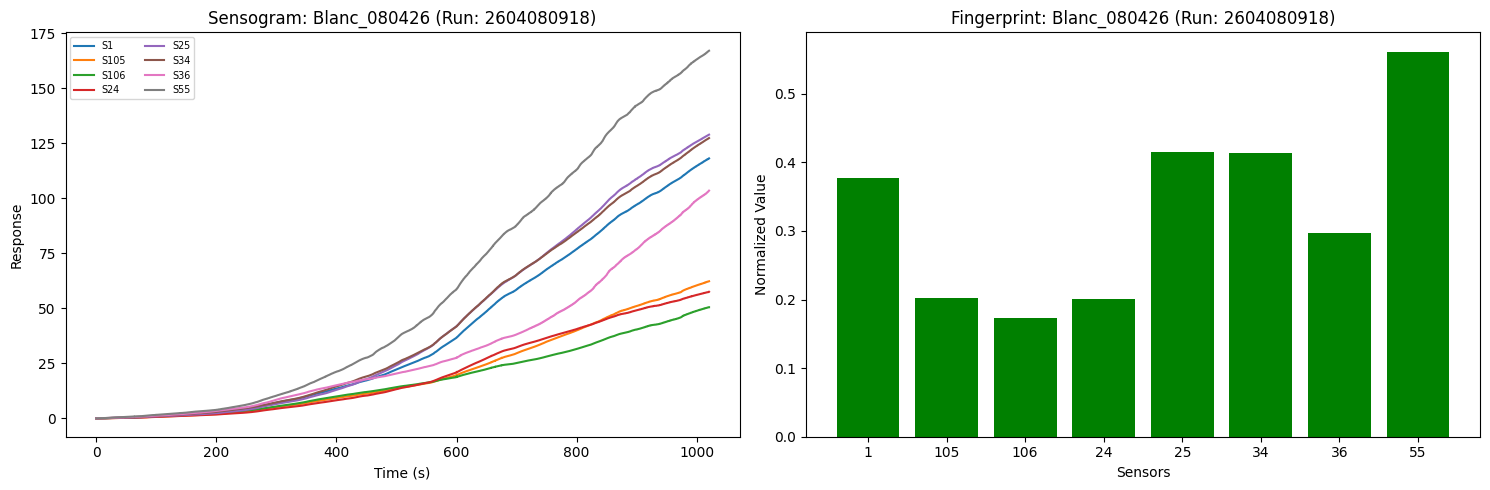

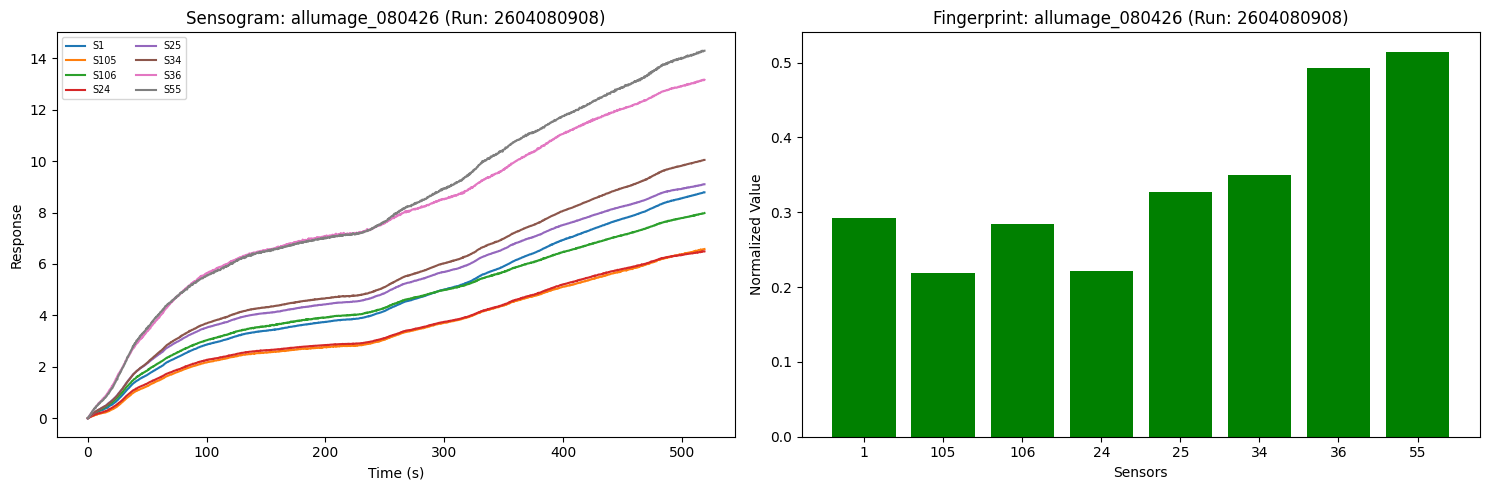

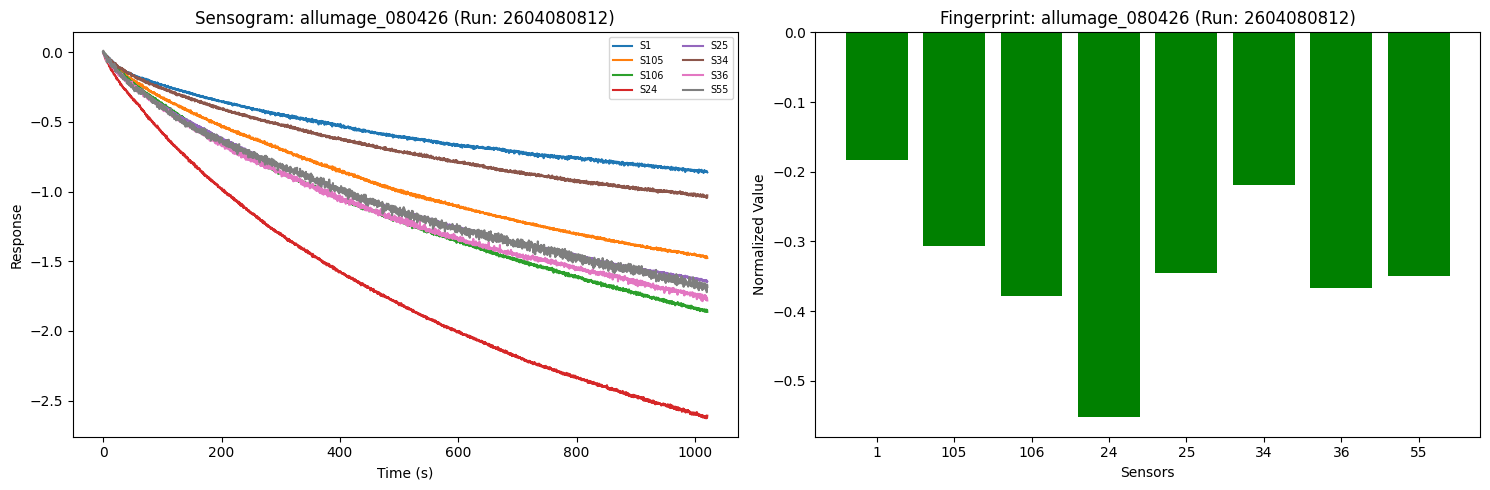

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load datasets
signatures = pd.read_csv('7Q27.normalized.signatures.csv')
sensograms = pd.read_csv('7Q27.sensograms.csv')

# Sensor list
sensors = ['1', '105', '106', '24', '25', '34', '36', '55']

# Iterate through EVERY row in the signatures file
for index, row in signatures.iterrows():
    run_id = row['run_id']
    item = row['item']
    
    # Filter sensogram data for this specific unique run_id
    run_sensogram = sensograms[sensograms['run_id'] == run_id]
    
    # Create side-by-side plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Left: The Sensogram (The dynamic peaks you see during the run)
    for s in sensors:
        ax1.plot(run_sensogram['relative_time_sec'], run_sensogram[s], label=f'S{s}')
    ax1.set_title(f'Sensogram: {item} (Run: {run_id})')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Response')
    ax1.legend(ncol=2, fontsize='x-small')
    
    # Right: The Signature (The final fingerprint used for ML)
    ax2.bar(sensors, row[sensors], color='green')
    ax2.set_title(f'Fingerprint: {item} (Run: {run_id})')
    ax2.set_xlabel('Sensors')
    ax2.set_ylabel('Normalized Value')
    
    plt.tight_layout()
    plt.show()
    
    # Optional: Close plot to save memory if you have hundreds of records
    # plt.close(fig)